In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

In [2]:
# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner
from frank.utilities import convolve_profile

In [3]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d.frank2d import Frank2D 
from frank2d.geometry import Geometry
from frank2d.constants import rad_to_arcsec
from frank2d.plot import Plot
from frank2d.fitting import IterativeSolverMethod

In [4]:
from scipy.special import j0
from scipy.stats import binned_statistic

In [5]:
from scipy.optimize import curve_fit

### Load data

In [6]:
# UVtable
dir = "../../data/"
disk_name = "SimulatedBlob"
data_file =  dir +"SimulatedBlob.txt"


# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [7]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [8]:
geom_f2d = Geometry(inc, pa, dra, ddec)
geom_Ring = geom_f2d

In [9]:
Rmax = 2*rout
Qmax = max(np.hypot(u,v))
import math
N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

### Create the ring in uv-space

In [10]:
# Deprojection
du, dv, _ = geom_f2d.deproject(u, v)
dbaseline = np.hypot(du, dv)

baseline = np.hypot(u, v)

In [11]:
baseline_ring = baseline
u_ring = u
v_ring = v

In [12]:
Re_ring = np.median(Re[np.where(baseline_ring<3e4)])*np.real(j0(2.*np.pi*(Rmax/rad_to_arcsec/2.)*baseline_ring))

In [13]:
Imag_ring = np.zeros(len(Re))
Vis_ring = Re_ring + Imag_ring*1j

In [14]:
uvtable = {'u': u_ring, 'v': v_ring, 'vis': Vis_ring, 'weights': Weights}


### Frank2D

In [15]:
frank2d = Frank2D(N, Rmax)

In [16]:
frank2d.process_vis(uvtable)


===>  Setting gridded data...


### Best

In [17]:
frank2d.search_MAP()

Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 271.19 seconds
--> Calculating m_log_posterior with m, logc, logl: 0 -2.0 4.0
----------- m_log_post: -1049860453.0251064 -----------
  + jDj: 2099753896.2371514
  + mu:  4623101124672.984
  + j:  0.0681228272646049
Setting the initial guess...
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1049840819.8119595 -----------
  + jDj: 2099703684.2964373
  + mu:  4623102427613.43
  + j:  0.0681228272646049
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1049840819.8119595 -----------
  + jDj: 2099703684.2964373
  + mu:  4623102427613.43
  + j:  0.0681228272646049
Optimizing the posterior...
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1049840819.8119595 -----------
  + jDj: 2099703684.2964373
  + mu:  4623102427613.43
  + j:  0.0681228272646049
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.1 4.0
----------- m_lo

In [18]:
best = frank2d.MAP
best

{'m': -0.8149691582556347, 'c': 295.08841450502865, 'l': 56853.41680381111}

### Run a new Frank2D Object

##### Run for different N's to find N to compare with CLEAN

In [17]:
best = {'m': -0.8149691582556347, 'c': 295.08841450502865, 'l': 56853.41680381111}

In [18]:
#Ns = [ceil(0.5*N), ceil(N), ceil(1.25*N), ceil(1.5*N), ceil(1.75*N), ceil(2*N), ceil(2.5*N), ceil(3*N)]

In [66]:
ls = [5e4]

In [67]:
resolutions = []
resolutions_error = []

In [68]:
Rmax

2

xxxxxxxxxxxxxxxxxxxxxx l = 50000.0  xxxxxxxxxxxxxxxxxxxxxx


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -0.8149691582556347, 'c': 295.08841450502865, 'l': 50000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.56 seconds
        +  Building system = 0.03  min |  1.58 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 86/50000 [00:10<1:41:29,  8.20 iterations/s]


            +  BiCGStab = 0.18  min |  10.56 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.0008256898168824936,
 'iterations': 86,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-12}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  7.43 seconds
--> times building full visibility model = 0.12  min |  7.47 seconds


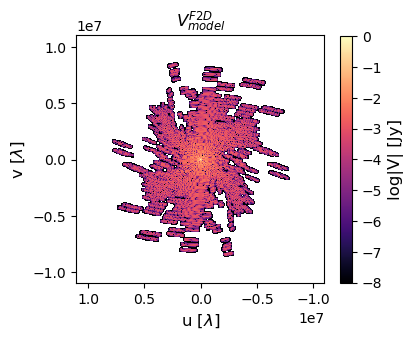

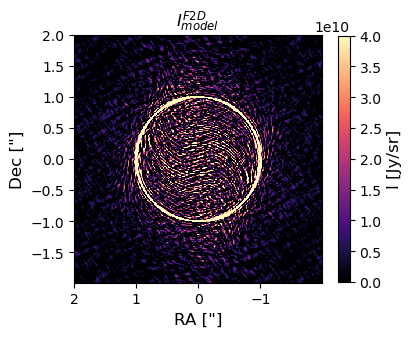

FWHM= 0.022954362661008993 +/- 0.00023837759666411995 arcsec


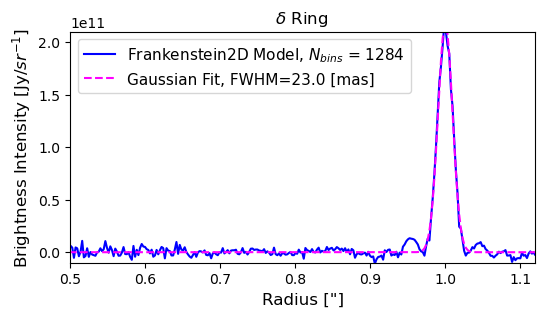

In [78]:
for l in ls:
    print("xxxxxxxxxxxxxxxxxxxxxx l =", l, " xxxxxxxxxxxxxxxxxxxxxx")
    frank2d2 = Frank2D(N, Rmax)
    frank2d2.fit( data = uvtable, kernel_params = {'m': best['m'], 'c': best['c'], 'l':l}, rtol=1e-12)
    Plot_ = Plot(frank2d2, geom_f2d)
    Plot_.visibility(fig_size = 4,  title= r'$V_{model}^{F2D}$', size_label=12, vmax= 0, vmin= -8)
    Plot_.intensity(fig_size = 4, zoom=1, size_label=12, gamma =1)

    def gauss(r, sigma):
        return np.exp(-0.5*((r-Rmax/2.)/sigma)**2)

    # FWHM
    # deproject
    x_model_1d, y_model_1d = geom_f2d.deproject_xy(Plot_._x_model_1d, Plot_._y_model_1d)
    x_model, y_model = Plot_._x_model, Plot_._y_model

    I = Plot_._int_model

    r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
    bins_f2d = 3*N
    r = np.linspace(r_.min(), r_.max(), bins_f2d)
    edges = Plot_.edges(r)

    r_f2d, I_f2d = Plot_.get_profile(x_model, y_model, I, bins = edges)
    I_f2d = np.nan_to_num(I_f2d, nan=0)

    popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
    FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
    Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

    plt.close()
    plt.figure(figsize=(6,3))
    plt.plot(r_f2d, I_f2d, color='blue',label= r'Frankenstein2D Model, $N_{bins}$ = '+ str(bins_f2d))
    plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), ls = '--', color='magenta', label='Gaussian Fit, FWHM=%.1f [mas]'%(FWHM_frank2d*1000))
    plt.ylabel(r'Brightness Intensity [Jy/$sr^{-1}$]', size=12)
    plt.xlabel('Radius ["]', size=12)
    plt.xlim(0.5, 1.12)
    plt.ylim(-1e10, 2.1e11)

    plt.title(r'$\delta$ Ring ')
    plt.legend(loc='upper left', fontsize = 11)
    
    resolutions.append(FWHM_frank2d)
    resolutions_error.append(Error_FWHM_f2d)

    print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

In [27]:
custom_ticks = [10000.0, 20000.0, 40000.0, 50000.0, 70600.20854903864, 90000.0]
custom_labels = [f"{x:.0e}" for x in custom_ticks] 

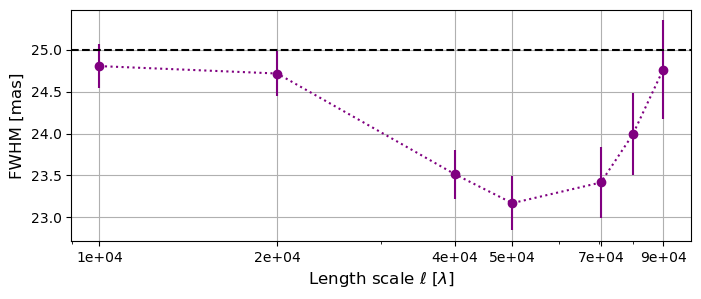

In [40]:
plt.figure(figsize=(8,3))
plt.errorbar(ls, np.array(resolutions)*1000, yerr=np.array(resolutions_error)*1000, fmt='o:', color='purple')
plt.xlabel(r'Length scale $\ell$ $[\lambda]$' , size =12)
plt.axhline(y=25, color='k', linestyle='--')
plt.minorticks_off()
plt.ylabel('FWHM [mas]', size =12)
plt.xscale('log')
plt.xticks(custom_ticks, custom_labels)
plt.grid()
plt.show()

### FWHM

In [30]:
# deproject
x_model_1d, y_model_1d = geom_f2d.deproject_xy(Plot_._x_model_1d, Plot_._y_model_1d)
x_model, y_model = Plot_._x_model, Plot_._y_model

In [31]:
I = Plot_._int_model

In [32]:
r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
bins_f2d = 2*N
r = np.linspace(r_.min(), r_.max(), bins_f2d)
edges = Plot_.edges(r)

In [33]:
r_f2d, I_f2d = Plot_.get_profile(x_model, y_model, I, bins = edges)

In [34]:
I_f2d = np.nan_to_num(I_f2d, nan=0)

In [35]:
popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

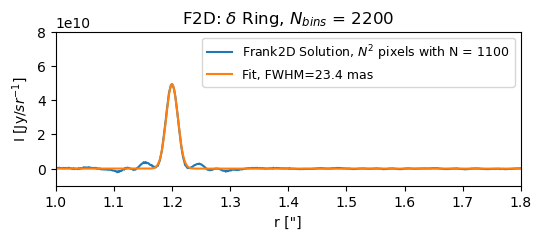

In [36]:
plt.close()
plt.figure(figsize=(6,3))
plt.plot(r_f2d, I_f2d, color='C0',label= r'Frank2D Solution, $N^{2}$ pixels with N = ' + str(N))
plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(1, 1.8)
plt.ylim(-1e10, 8e10)

plt.title(r'F2D: $\delta$ Ring, $N_{bins}$ = '+ str(bins_f2d))
plt.legend(loc='best', fontsize = 9)

In [37]:
print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

FWHM= 0.023437725912044398 +/- 0.00020033245478667116 arcsec


### Frank1D

In [38]:
# UVtable
dir = "../../../data/uvtables/"
data_file = dir +'uvtable_' + disk_name + '_continuum_1d.txt'

 # load data||
u_f1d, v_f1d, Re_f1d, Imag_f1d, Weights_f1d = u, v, Re, Im, Weights
Vis_f1d = Re_f1d + Imag_f1d*1j

In [39]:
u_f1d_d, v_f1d_d, _ = geom_f2d.deproject(u_f1d, v_f1d)
dbaseline_f1d = np.hypot(u_f1d_d, v_f1d_d)
baseline_f1d = np.hypot(u_f1d, v_f1d)

In [40]:
baseline_ring_f1d = dbaseline_f1d

In [41]:
Re_ring = np.median(Re_f1d[np.where(baseline_ring_f1d<3e4)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2.)*baseline_ring_f1d))

In [42]:
Imag_ring = np.zeros(len(Re_ring))
Vis_f1d = Re_ring + Imag_ring*1j

In [43]:
rout

2.4

In [44]:
# Frank 1D parameters
n_pts = 1100
alpha = 1.05
w_smooth = 1e-4
r_out = rout

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, Vis_f1d, Weights_f1d)

KeyboardInterrupt: 

In [ ]:
r_f1d = sol.r
I_f1d = sol.mean

In [ ]:
#Plot_2 = Plot(frank2d, geom_f2d)

#r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
#r_ = r_f1d

#bins = 500
#r = np.linspace(r_.min(), r_.max(), bins)
#edges = Plot_.edges(r)

#r_f1d, I_f1d = Plot_.get_profile(sol.r, sol.r, sol.mean, bins = edges, fit_1d = True)

#I_f1d = np.nan_to_num(I_f1d, nan=0)

In [ ]:
popt_frank1d, cov_frank1d = curve_fit(gauss, r_f1d, I_f1d/np.max(I_f1d), p0=[0.02])
FWHM_frank1d = popt_frank1d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [ ]:
print ('FWHM=', FWHM_frank1d, '+/-', Error_FWHM_frank1d, 'arcsec')   

FWHM= 0.014728107962258659 +/- 0.00016069426374943485 arcsec


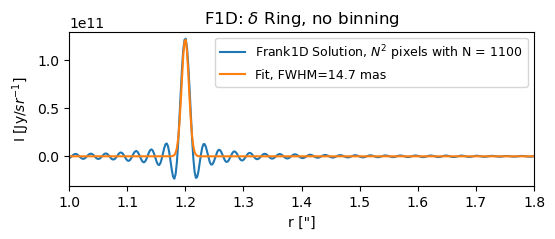

In [48]:
plt.close()
plt.figure(figsize=(6,2))
plt.plot(r_f1d, I_f1d, color='C0',label= r'Frank1D Solution, $N^{2}$ pixels with N = ' + str(n_pts))
plt.plot(r_f1d, gauss(r_f1d, *popt_frank1d)*np.max(sol.mean), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(1, 1.8)
plt.title(r'F1D: $\delta$ Ring, no binning')
plt.legend(loc='best', fontsize = 9)

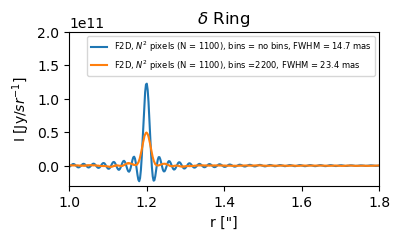

In [68]:
plt.close()
plt.figure(figsize=(4,2))
plt.plot(r_f1d, I_f1d,label= r'F2D, $N^{2}$ pixels (N = ' + str(N) + '), bins ='+  ' no bins' + ', FWHM = %.1f mas'%(FWHM_frank1d*1000))
plt.plot(r_f2d, I_f2d, label= r'F2D, $N^{2}$ pixels (N = ' + str(N) + '), bins ='+  str(bins_f2d) + ', FWHM = %.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(1, 1.8)
plt.ylim(-3e10, 2e11)
plt.title(r'$\delta$ Ring')
plt.legend(loc='best', fontsize = 6)

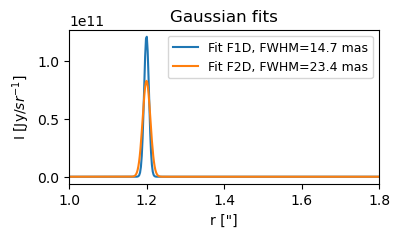

In [69]:
plt.close()
plt.figure(figsize=(4,2))
plt.plot(sol.r, gauss(sol.r, *popt_frank1d)*np.max(sol.mean), label='Fit F1D, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.plot(r, gauss(r, *popt_frank2d)*np.max(I), label='Fit F2D, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(1, 1.8)
plt.title('Gaussian fits')
plt.legend(loc='best', fontsize = 9)

### Convolve to the f2d beam

In [143]:
sigma_final = np.sqrt(FWHM_frank2d**2 - FWHM_frank1d**2)
sigma_final

0.01795838309477733

In [144]:
beam_1mm = {'bmaj':sigma_final, 'bmin':sigma_final, 'beam_pa':geom.PA}
convolved_frank1d = convolve_profile(r_f1d, I_f1d, geom.inc, geom.PA, beam_1mm)

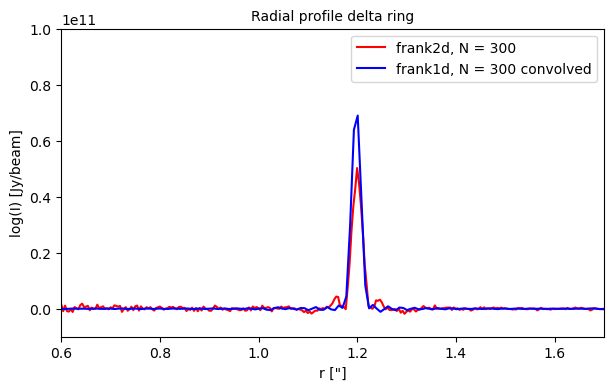

In [145]:
plt.figure(figsize=(7, 4))
plt.plot(r_f2d, I_f2d, "red", label=r'frank2d' + ', N = ' +str(n_pts))
plt.plot(r_f1d, convolved_frank1d, "blue", label=r'frank1d' + ', N = ' +str(N)+ ' convolved')
plt.title(r'Radial profile delta ring', size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.xlim(0.6, 1.7)
plt.ylim(-1e10, 10e10)
plt.legend(fontsize=10)
plt.show()

In [69]:
popt_frank1d_conv, cov_frank1d_conv = curve_fit(gauss, r_f1d, convolved_frank1d/np.max(convolved_frank1d), p0=[0.009])
FWHM_frank1d_conv = popt_frank1d_conv[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d_conv = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [70]:
FWHM_frank1d_conv

0.0225764452262478

### Trying with real disk

In [11]:
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [12]:
N = 300
best = {'m': -1.011407337728121, 'c': 222.9257843669846, 'l': 46452.74921193543}

In [13]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [14]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.02  min |  1.37 seconds
--> time = 0.02  min |  1.41 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 3.5986215447871888
Final tolerance :  3.5986215447871888
.... iteration:  0
                        -> actual tol:  359862154.4787189 vs  3.5986215447871888
.... iteration:  1
                        -> actual tol:  16248311.289388938 vs  3.5986215447871888
.... iteration:  2
                        -> actual tol:  12793022.141465731 vs  3.5986215447871888
.... iteration:  3
                        -> actual tol:  17458649.174258534 vs  3.5986215447871888
.... iteration:  4
                        -> actual tol:  3767348.9717458216 vs  3.5986215447871888
.... iteration:  5
                        -> actual tol:  5315434.46853328 vs  3.5986215447871888
.... iteration:  6
                        -> actual tol:  1524640.4976162645 vs 

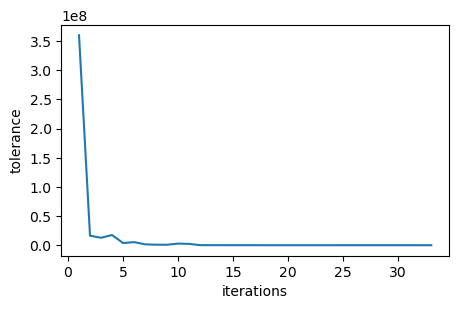

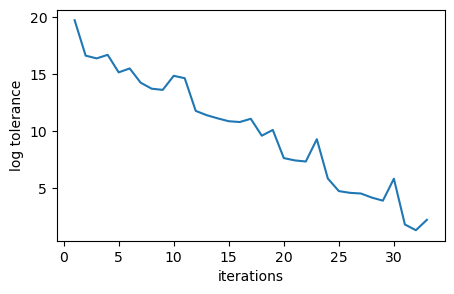

--> time = 0.02  min |  0.93 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   False
Building full visibility model...
F2D model in 28.01 seconds.


In [15]:
start_time = time.time()


frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time):.2f} seconds.")

In [16]:
FWHM_frank2d = 0.022905863089907247
FWHM_frank1d = 0.011191120375380921

In [17]:
Plot_ = Plot(frank2d, geom)

In [18]:
from astropy.io import fits
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'

fits_name = dir + disk

In [19]:
Plot_.set_fits_file(fits_name)

In [20]:
sol_f1d = frank2d.frank1d(uvtable, alpha=1.2, w_smooth=1e-3, n_pts=300, rout=rout, geom=geom)

Performing 1D Frank fit...

$\alpha$ =  1.2  and $w_{smooth}$ =  0.001

N =  300  and $R_{max}$ =  1.9


In [21]:
Plot_.set_f1d_solution(sol_f1d)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.022905863089907247 arcsec
-> Final beam to convolve with: 0.03059095415189107 x 0.028063616248335515 arcsec
FWHM for frank1d: 0.011191120375380921 arcsec
-> Final beam to convolve with: 0.0365409888284432 x 0.034452923614276196 arcsec


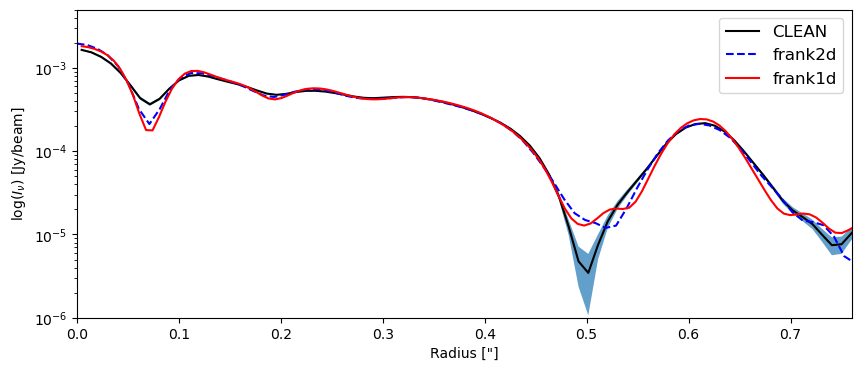

In [22]:
Plot_.intensity_profile(   clean = True, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d
                        )

UnboundLocalError: cannot access local variable 'y_lims_sr' where it is not associated with a value

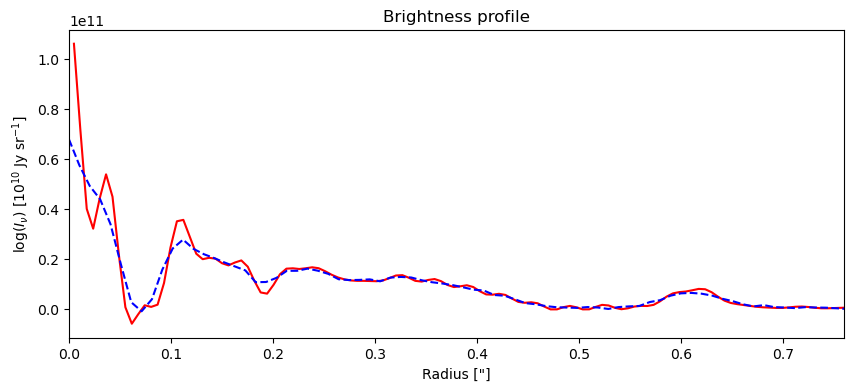

In [24]:
Plot_.intensity_profile(   clean = False, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d, 
                            y_lims = (1e8, 1e12)
                        )